# Exploratory Data Analysis

[Dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

In [2]:
# Modules
import zipfile
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
import numpy as np

In [3]:
# Data Import
with zipfile.ZipFile('../Data/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('../Data')

df = pd.read_csv('../Data/housing.csv')
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Pair Plotting
- Used data wrangler to view distributions of single variables
- Some missing data in bedrooms category
- All numeric except ocean proximity which is categorical - needs one hot encoded

In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Do pairs plots

<Figure size 400x400 with 0 Axes>

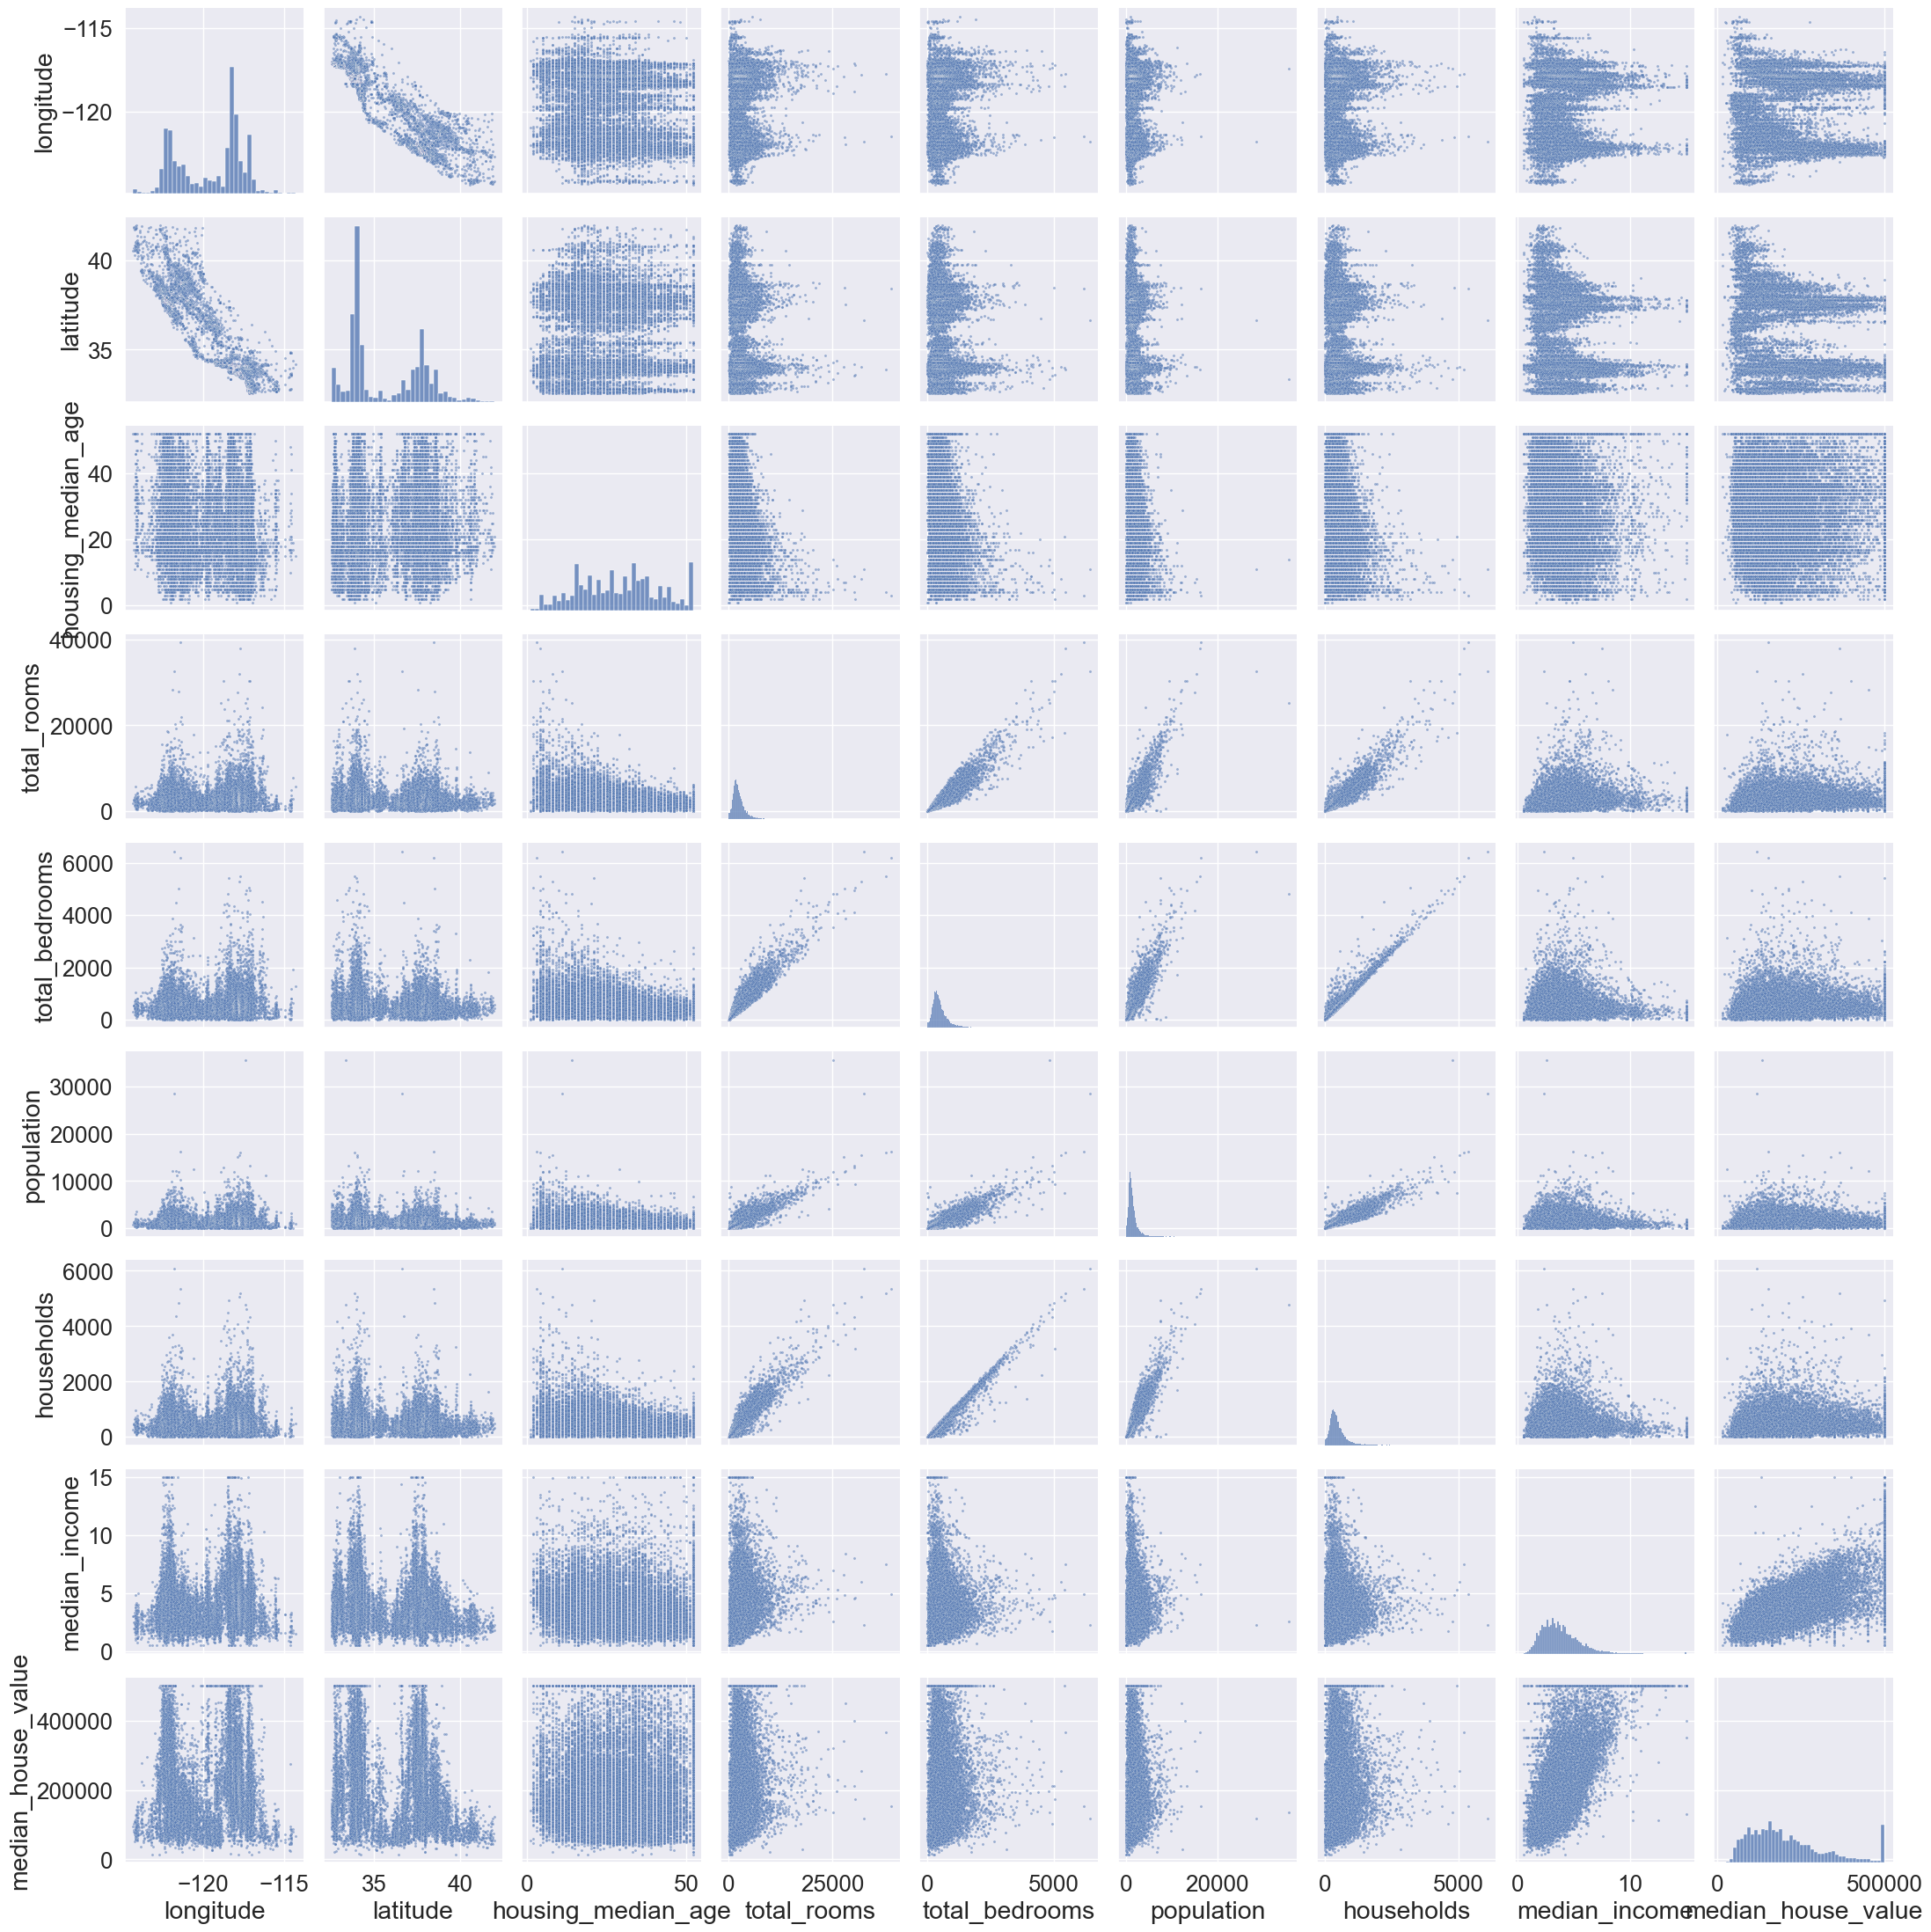

In [4]:
plt.figure(figsize=(4, 4))
sns.set(font_scale=1.7)
sns.pairplot(df, plot_kws={'alpha':0.5, 's':5})
plt.show()

- Median house value caps out at $500,000
- House median age caps out at 52
- Outlier of 15 in median income
- Note all data is a median of all households within that block, households column gives number of homes in that block
- Households has a long thin tail, is near normal in log space

In [5]:
print('Blocks with over 4000 households:', (df['households']>4000).sum())
print('Blocks with median house price over $500,000:', (df['median_house_value']>=500000).sum(), (df['median_house_value']>=500000).sum()/df.shape[0]*100)
print('blocks with median housing age over 52:', (df['housing_median_age']>=52).sum(), (df['housing_median_age']>=52).sum()/df.shape[0]*100)

Blocks with over 4000 households: 15
Blocks with median house price over $500,000: 992 4.8062015503875966
blocks with median housing age over 52: 1273 6.167635658914729


<Axes: xlabel='housing_median_age', ylabel='Count'>

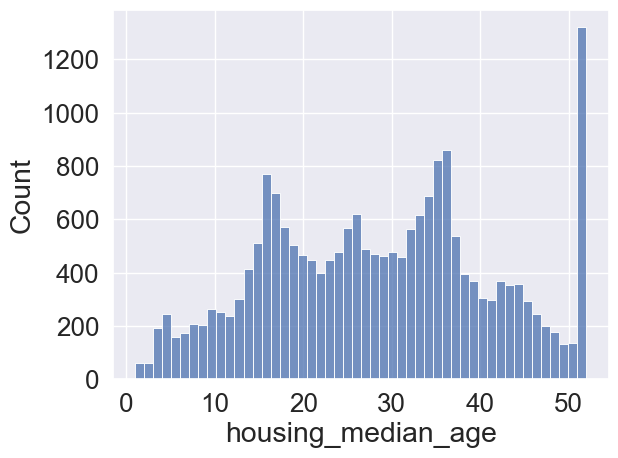

In [6]:
sns.histplot(df['housing_median_age'], bins=50, kde=False)


<Axes: xlabel='median_income', ylabel='Count'>

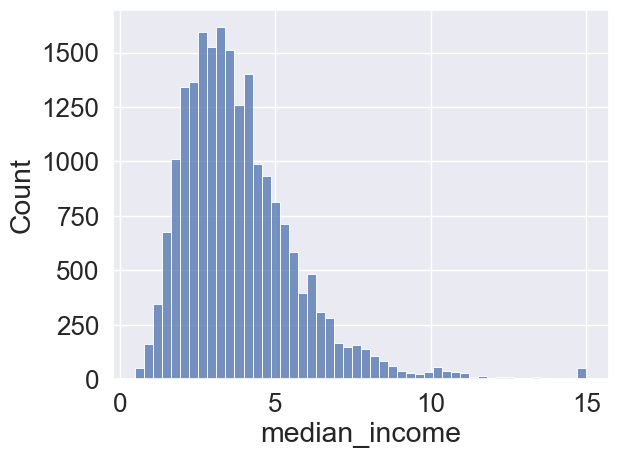

In [7]:
sns.histplot(df['median_income'], bins=50, kde=False)

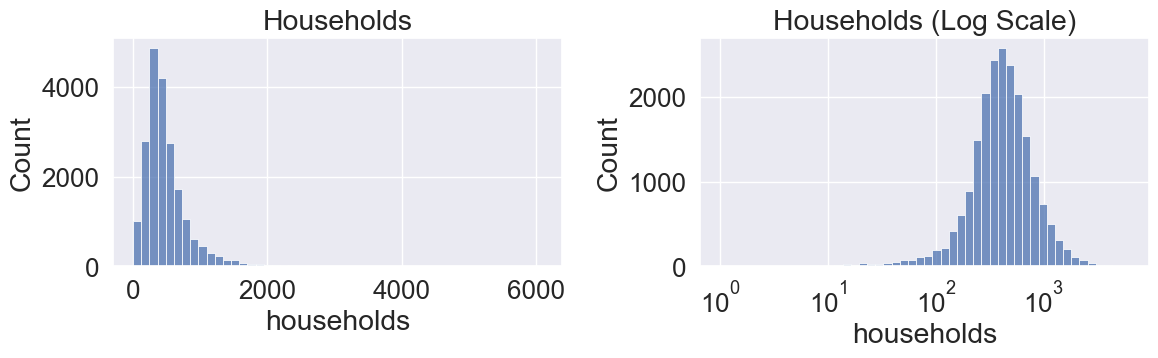

In [8]:
#sns.histplot(df['households'], bins=50, kde=False)
#sns.histplot(df['households'], bins=50, kde=False, log_scale=True)

# Plot two histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['households'], bins=50, kde=False, ax=axes[0])
axes[0].set_title('Households')

sns.histplot(df['households'], bins=50, kde=False, log_scale=True, ax=axes[1])
axes[1].set_title('Households (Log Scale)')

plt.tight_layout()
plt.show()

## Geographic Plots

In [11]:
import plotly.express as px

#fig = go.Figure(data = go.Scattergeo(lon = df['longitude'], lat = df['latitude'],))
#fig = px.scatter_map(df, lat="latitude", lon="longitude", color="median_house_value")

#fig.update_layout(
#    mapbox_style="open-street-map",
#    margin={"r":0,"t":0,"l":0,"b":0})

#fig.show()

for i in range(0, df.shape[1]):
    col = df.columns[i]

    if not pd.api.types.is_numeric_dtype(df[col]):
        continue
    else:

        vmin = df[col].quantile(0.01)
        vmax = df[col].quantile(0.99)

    fig = px.scatter_map(df, lat="latitude", lon="longitude", color=col, range_color=[vmin, vmax], color_continuous_scale='Blues')
    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
    fig.show()

C:\Users\yy21473\AppData\Local\Temp\ipykernel_36804\51916000.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



<Axes: xlabel='median_house_value', ylabel='Count'>

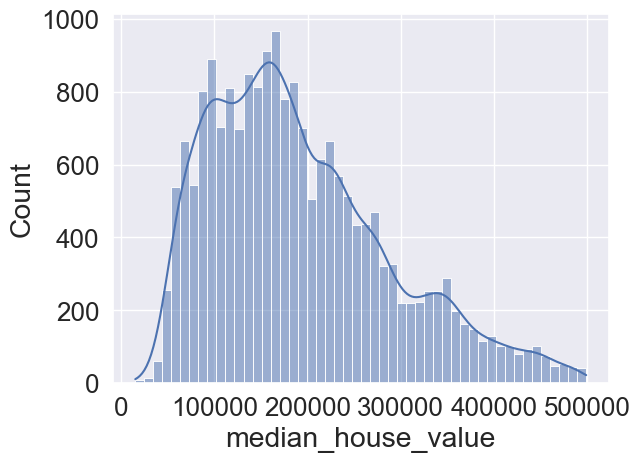

In [12]:
dfNoMax = df[df['median_house_value']<500000]

dfNoMax['median_house_value_log'] = np.log(dfNoMax['median_house_value'])

sns.histplot(dfNoMax['median_house_value'], bins=50, kde=True)

Mean: 12.032503216041802, Standard Deviation: 0.5321311171493062


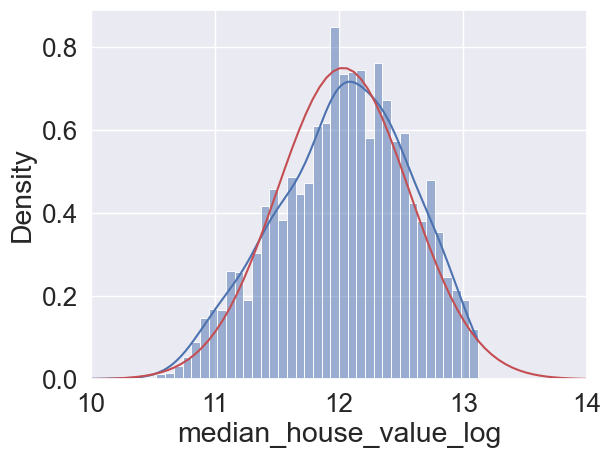

In [14]:
import scipy.stats as stats

fig2, ax2 = plt.subplots()

sns.histplot(dfNoMax['median_house_value_log'], bins=50, kde=True, kde_kws={'bw_adjust': 2}, ax=ax2, stat='density')
ax2.set_xlim(10, 14)

mu, sigma = stats.norm.fit(dfNoMax['median_house_value_log'])
print(f"Mean: {mu}, Standard Deviation: {sigma}")

x=np.linspace(dfNoMax['median_house_value_log'].min()-1, dfNoMax['median_house_value_log'].max()+1, 100)
normalDistribution = stats.norm.pdf(x, mu, sigma)
ax2.plot(x, stats.norm.pdf(x, loc=mu, scale=sigma), 'r-', label='Normal Distribution Fit')


In [45]:
dfNoMax['median_house_value_log'].max()

#return probability of values greater than 13.12
prob = 1 - stats.norm.cdf(dfNoMax['median_house_value_log'].max(), loc=mu, scale=sigma)
print(prob)

print('Number of samples expected to be > $500,000:', prob*df.shape[0])  # expected number of values greater than 13.12

0.020441290819220304
Number of samples expected to be > $500,000: 421.9082425087071
